In [2]:
import os
print(os.listdir())  # see what files are actually in the folder

['.git', '.gitignore', '.venv', '.virtual_documents', '1 - NLP Data Collection.ipynb', '2 - Exploratory Data Analysis.ipynb', '2 - NLP Data Preprocessing.ipynb', '2-2.2 Rappler.ipynb', '2.2 - Topic Modeling.ipynb', '3.1 Term-Frequency Language Models.ipynb', 'basic_stopwords.txt', 'comments_with_topics.xlsx', 'domain_stopwords.txt', 'Impeachment_Analysis.ipynb', 'method-1-youtube', 'MultiSource_Topic_Analysis.ipynb', 'rappler.xlsx', 'RapplerMultiple.ipynb', 'Rappler_Analysis.ipynb', 'rappler_with_comments.xlsx', 'rappler_with_topics.xlsx', 'README.md', 'reddit_comments.csv', 'topic0.png', 'topic1.png', 'topic2.png', 'topic3.png', 'topic4.png', 'topic_documents.xlsx', 'youtube_comments_with_topics.xlsx']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


pyLDAvis version: 3.4.0
✅ Loaded rows: 3312 | Sources: ['Rappler', 'Reddit', 'YouTube']
AI-filtered rows: 206 / 3312


C:\Users\DELL\AppData\Local\Temp\ipykernel_14912\2949540893.py:192: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data_ai = data[data["Text"].str.lower().str.contains(ai_regex, na=False)].copy()
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\DELL\AppData\Local\Temp\ipykernel_14912\2949540893.py:218: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([pd.Grouper(freq=FREQ), "sentiment"])


k=3 → perplexity=851.41, logLik=-484184
k=5 → perplexity=850.04, logLik=-484069
k=7 → perplexity=840.52, logLik=-483260
k=10 → perplexity=853.74, logLik=-484380


Best k: 7


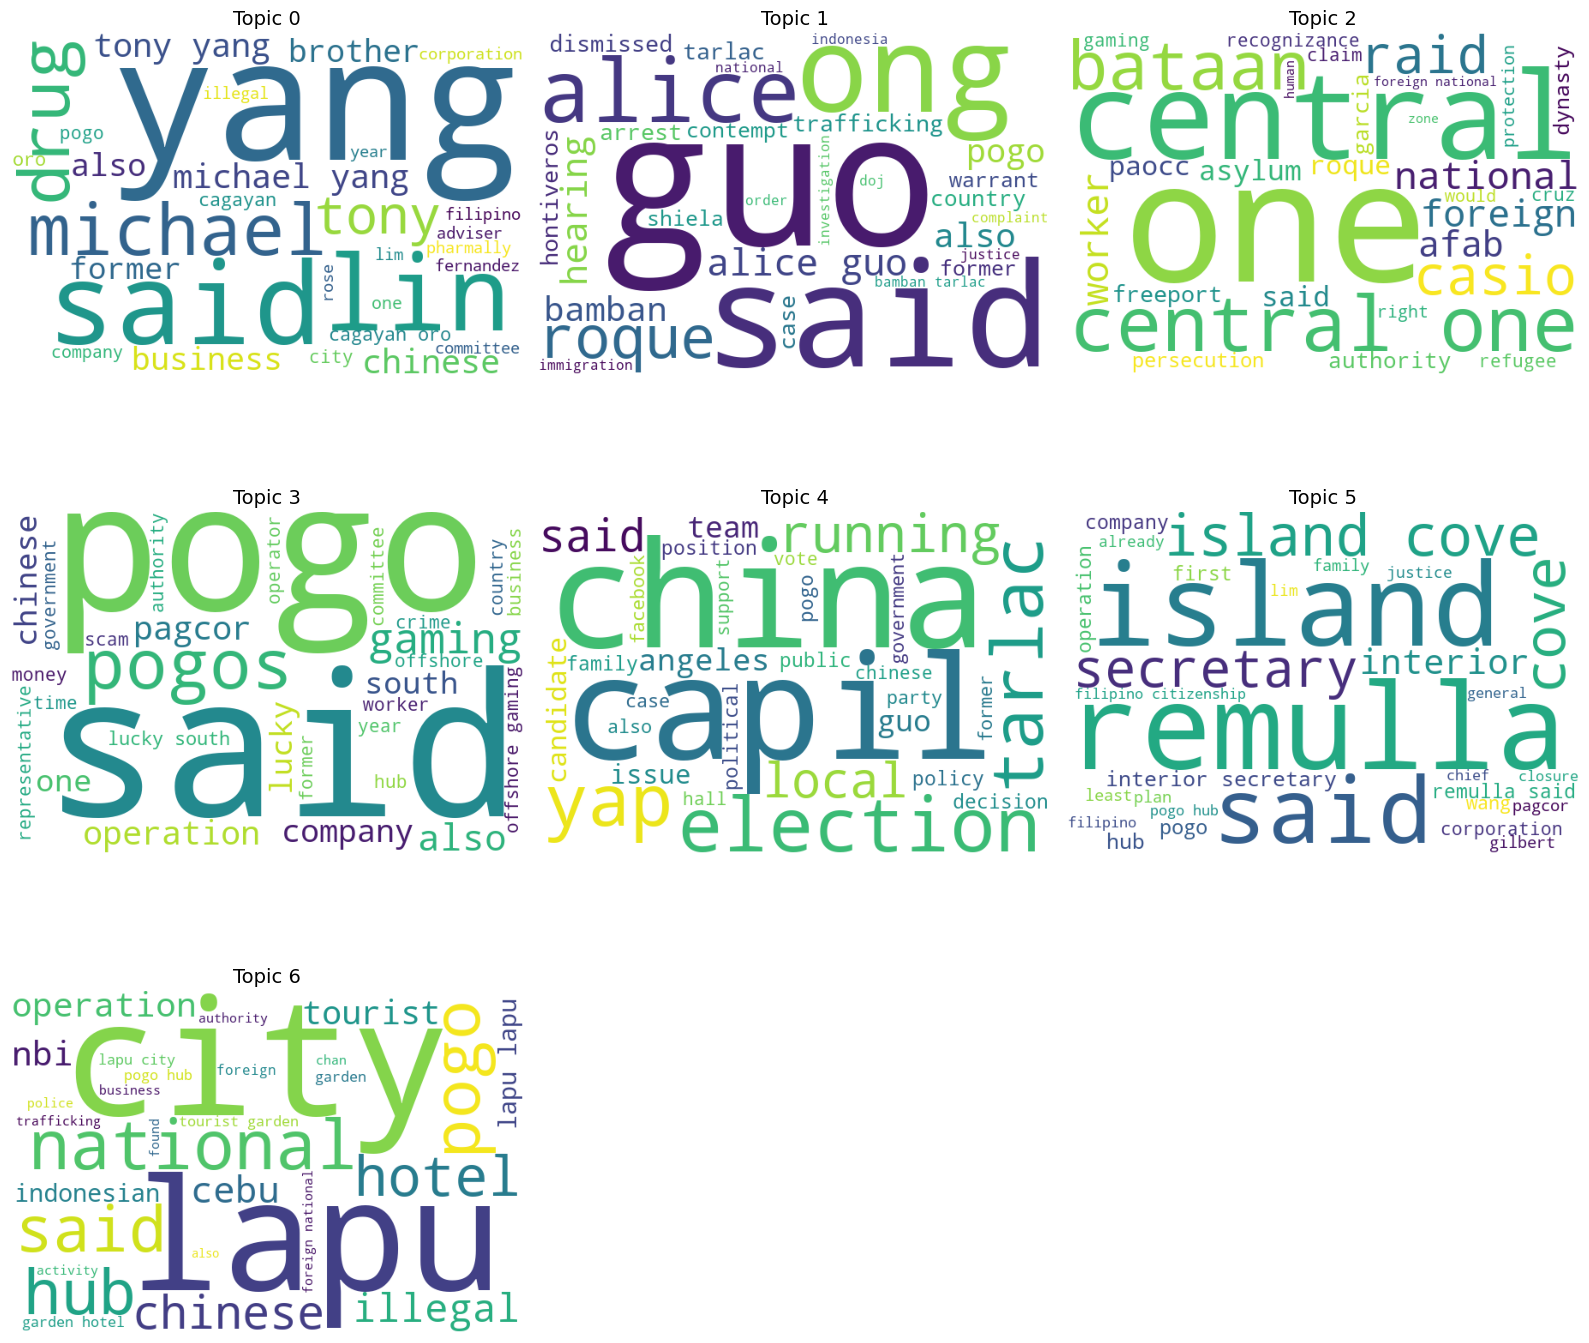

DONE.
Saved files:
- model_comparison.html
- pyldavis_topics.html
- topic_dashboard.html
- topic_topwords.html
- topic_wordclouds.png + topicN.png
- labeled_topics.xlsx
- labeled_topics_ai_only.xlsx (AI-filtered)


In [ ]:
import pandas as pd, numpy as np, re, os
import matplotlib.pyplot as plt
from math import ceil
from wordcloud import WordCloud
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords'); nltk.download('wordnet'); nltk.download('omw-1.4'); nltk.download('punkt')

# Topic modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis
import pyLDAvis.lda_model as pyLDAvis_lda
print("pyLDAvis version:", pyLDAvis.__version__)

# Choose: "reddit", "rappler", "youtube", or "all"
SOURCE_MODE = "all"   # or "reddit"

REDDIT_CSV  = "reddit_comments.csv"          
RAPPLER_XLS = "rappler.xlsx"                 
YOUTUBE_FILE = "youtube_comments_with_topics.xlsx"

# Global settings
K_LIST = (3,5,7,10)
MAX_FEATURES = 1500

def load_youtube(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        print(f"⚠️ YouTube file not found: {path}")
        return pd.DataFrame()
    try:
        if path.lower().endswith((".xlsx", ".xls")):
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path)
    except Exception as e:
        print(f"❌ Failed to read YouTube file: {e}")
        return pd.DataFrame()

    # Try to find a usable text column
    txt = next((c for c in ["text","comment","body","Content","content","message"] if c in df.columns), None)
    if not txt:
        print(f"❌ No text column found in YouTube file. Columns: {df.columns.tolist()}")
        return pd.DataFrame()

    df["Text"] = df[txt].astype(str)
    # Optional: check if there's already a "processed" column
    if "processed" in df.columns:
        df_out = df.rename(columns={"processed":"processed"}).copy()
    else:
        df["processed"] = df["Text"].apply(lambda s: clean_text(s, YOUTUBE_STOPWORDS))
        df_out = df[df["processed"].str.len() > 0].reset_index(drop=True)

    df_out["Source"] = "YouTube"
    return df_out


# ========== Stopwords (global + per-source) ==========
def load_file_words(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return {w.strip().lower() for w in f if w.strip()}
    except FileNotFoundError:
        return set()

en = set(stopwords.words("english"))
fil = {
    'mga','ang','ng','sa','na','ay','ko','mo','nya','namin','nila','yan','yun','yung','lang','din','rin',
    'pa','ba','eh','ah','oo','hindi','wala','meron','may','kasi','pero','tapos','kaya','sana','naman',
    'talaga','sobra','grabe','daw','raw','para','dito','doon','ito','iyon','sila','kami','tayo','akin',
    'amin','atin','inyo','kanila','kanyang','sarili'
}
news_politics = {
    'rappler','philippines','philippine','manila','duterte','marcos','aquino','arroyo','estrada','ramos',
    'president','vice','senator','congress','mayor','governor','admin','administration','republic',
    'senate','house','supreme','court','ombudsman','comelec','coa','csc','news','report','according',
    'officials','statement','press','release','conference','interview','monday','tuesday','wednesday',
    'thursday','friday','saturday','sunday','january','february','march','april','may','june','july',
    'august','september','october','november','december'
}
reddit_ui = {
    'reddit','subreddit','r','u','op','mods','mod','admin','admins','automod','flair','nsfw','spoiler',
    'upvote','downvote','upvoted','downvoted','karma','edit','link','thread','post','posted','comment','comments',
    'lol','lmao','imo','imho','idk','tbh','btw','source','via'
}
youtube_ui = {
    'youtube','channel','subscribe','like','comment','comments','video','watch','yt','shorts',
    'playlist','views','viewers','live','premiere','description','link'
}
basic_stop = load_file_words("basic_stopwords.txt")
domain_stop = load_file_words("domain_stopwords.txt")

BASE_STOPWORDS = en | fil | news_politics | basic_stop | domain_stop
REDDIT_STOPWORDS = BASE_STOPWORDS | reddit_ui
YOUTUBE_STOPWORDS = BASE_STOPWORDS | youtube_ui
RAPPLER_STOPWORDS = BASE_STOPWORDS  # Rappler uses the base set already

# ========== Helpers ==========
lemmatizer = WordNetLemmatizer()

def clean_text(s: str, stopset:set) -> str:
    if not isinstance(s, str): 
        return ""
    s = s.lower()
    s = re.sub(r'http\S+|www\S+|[\w\.-]+@[\w\.-]+\.\w+|@\w+|#\w+|\d+', ' ', s)  # urls, emails, handles, hashtags, numbers
    s = re.sub(r'[^\w\s]', ' ', s)   # keep words/spaces
    s = re.sub(r'\s+', ' ', s).strip()
    toks = [lemmatizer.lemmatize(t) for t in s.split() if len(t) > 2 and t.isalpha() and t not in stopset]
    return " ".join(toks)

def load_reddit(path):
    df = pd.read_csv(path)
    txt = next((c for c in ["body","comment","text","Content","content","message"] if c in df.columns), None)
    assert txt, f"No text column in Reddit CSV. Columns: {df.columns.tolist()}"
    df["Text"] = df[txt].astype(str)
    # date
    date_col = next((c for c in ["created_utc","created","date","timestamp"] if c in df.columns), None)
    if date_col:
        if np.issubdtype(df[date_col].dtype, np.number):
            df["Date"] = pd.to_datetime(df[date_col], unit="s", errors="coerce")
        else:
            df["Date"] = pd.to_datetime(df[date_col], errors="coerce")
    else:
        df["Date"] = pd.NaT
    df["Source"] = "Reddit"
    df["processed"] = df["Text"].apply(lambda s: clean_text(s, REDDIT_STOPWORDS))
    return df[df["processed"].str.len() > 0].reset_index(drop=True)

def load_rappler(path):
    if path.lower().endswith((".xlsx",".xls")):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    txt = next((c for c in ["Content","content","text","comment","body"] if c in df.columns), None)
    assert txt, f"No text column in Rappler file. Columns: {df.columns.tolist()}"
    df["Text"] = df[txt].astype(str)
    # date
    date_col = next((c for c in ["Publish Date","publish_date","date"] if c in df.columns), None)
    if date_col:
        df["Date"] = pd.to_datetime(df[date_col], errors="coerce")
    else:
        df["Date"] = pd.NaT
    df["Source"] = "Rappler"
    df["processed"] = df["Text"].apply(lambda s: clean_text(s, RAPPLER_STOPWORDS))
    return df[df["processed"].str.len() > 0].reset_index(drop=True)

# ========== Load data according to SOURCE_MODE ==========
parts = []

if SOURCE_MODE in ("reddit","all"):
    if os.path.exists(REDDIT_CSV):
        df_r = load_reddit(REDDIT_CSV)
        if not df_r.empty: parts.append(df_r)
    else:
        print(f"⚠️ Missing {REDDIT_CSV}; skipping Reddit")

if SOURCE_MODE in ("rappler","all"):
    if os.path.exists(RAPPLER_XLS):
        df_ra = load_rappler(RAPPLER_XLS)
        if not df_ra.empty: parts.append(df_ra)
    else:
        print(f"⚠️ Missing {RAPPLER_XLS}; skipping Rappler")

if SOURCE_MODE in ("youtube","all"):
    if os.path.exists(YOUTUBE_FILE):
        df_y = load_youtube(YOUTUBE_FILE)
        if not df_y.empty: parts.append(df_y)
    else:
        print(f"⚠️ Missing {YOUTUBE_FILE}; skipping YouTube")

# Ensure we actually have data
if not parts or all(p.empty for p in parts):
    raise SystemExit("❌ No data loaded. Add a file or change SOURCE_MODE.")

data = pd.concat(parts, ignore_index=True)
print("✅ Loaded rows:", len(data), "| Sources:", sorted(data["Source"].unique()))

# --- Keep only AI-related comments/posts ---
AI_KEYWORDS = [
    "ai","artificial intelligence","chatgpt","gpt","openai","llm","deepfake",
    "machine learning","ml","neural","automation","robot","copilot","midjourney",
    "stability ai","bard","gemini","image generator","autogpt","prompt","rag"
]
ai_regex = r"\b(" + "|".join([re.escape(k) for k in AI_KEYWORDS]) + r")\b"
data_ai = data[data["Text"].str.lower().str.contains(ai_regex, na=False)].copy()

print(f"AI-filtered rows: {len(data_ai)} / {len(data)}")
if data_ai.empty:
    print("⚠️ No AI-related comments found. Consider broadening AI_KEYWORDS or checking your sources.")

from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()
data_ai["compound"] = data_ai["Text"].apply(lambda s: sia.polarity_scores(str(s))["compound"])
data_ai["sentiment"] = pd.cut(
    data_ai["compound"],
    bins=[-1.0, -0.05, 0.05, 1.0],
    labels=["negative", "neutral", "positive"],
    include_lowest=True
)
# ensure Date is usable
data_ai["Date"] = pd.to_datetime(data_ai["Date"], errors="coerce")

# pick time granularity: "D" (day), "W" (week), or "M" (month)
FREQ = "W"

sent_time = (
    data_ai.dropna(subset=["Date"])
           .set_index("Date")
           .groupby([pd.Grouper(freq=FREQ), "sentiment"])
           .size()
           .reset_index(name="count")
)
# share per period
sent_time["share"] = sent_time["count"] / sent_time.groupby("Date")["count"].transform("sum")

import plotly.express as px
fig_sent = px.area(
    sent_time, x="Date", y="share", color="sentiment",
    title=f"Sentiment toward AI over time ({FREQ})",
    labels={"share":"share of comments"}
)
fig_sent.show()
fig_sent.write_html("ai_sentiment_over_time.html")

# optional: average sentiment by source over time
if "Source" in data_ai.columns:
    per_src = (
        data_ai.dropna(subset=["Date"])
               .set_index("Date")
               .groupby([pd.Grouper(freq=FREQ), "Source"])["compound"]
               .mean()
               .reset_index()
    )
    fig_src = px.line(
        per_src, x="Date", y="compound", color="Source",
        title=f"Average sentiment toward AI by source ({FREQ})",
        labels={"compound":"avg VADER compound"}
    )
    fig_src.show()
    fig_src.write_html("ai_sentiment_by_source.html")

# ========== Build LDA models ==========
def build_models(texts, stopset, k_list=K_LIST, max_features=MAX_FEATURES):
    vectorizer = CountVectorizer(
        max_df=0.95, min_df=2, stop_words=list(stopset),
        ngram_range=(1,2), max_features=max_features
    )
    X = vectorizer.fit_transform(texts)
    models = {}
    for k in k_list:
        lda = LatentDirichletAllocation(
            n_components=k, random_state=42, max_iter=20,
            learning_method='online', learning_decay=0.7
        )
        lda.fit(X)
        models[k] = {
            "model": lda, "vectorizer": vectorizer, "X": X,
            "perplexity": lda.perplexity(X), "log_lik": lda.score(X)
        }
        print(f"k={k} → perplexity={models[k]['perplexity']:.2f}, logLik={models[k]['log_lik']:.0f}")
    return models

# If AI filter has results, model on AI-only; otherwise fall back to all data
texts_for_topics = data_ai["processed"] if not data_ai.empty else data["processed"]
models = build_models(texts_for_topics, BASE_STOPWORDS)

# ========== Interactive model comparison ==========
k_vals = list(models.keys())
perp = [models[k]["perplexity"] for k in k_vals]
ll   = [models[k]["log_lik"] for k in k_vals]

fig_cmp = make_subplots(rows=1, cols=2,
    subplot_titles=["Perplexity (lower better)","Log Likelihood (higher better)"])
fig_cmp.add_trace(go.Scatter(x=k_vals, y=perp, mode="lines+markers", name="Perplexity"), row=1, col=1)
fig_cmp.add_trace(go.Scatter(x=k_vals, y=ll,   mode="lines+markers", name="LogLik"),    row=1, col=2)
fig_cmp.update_layout(title="Topic Model Comparison", height=420, showlegend=False)
fig_cmp.show()
fig_cmp.write_html("model_comparison.html")

# Choose best k by lowest perplexity
best_k = k_vals[int(np.argmin(perp))]
best = models[best_k]
lda, vec, X = best["model"], best["vectorizer"], best["X"]
print("Best k:", best_k)

# --- NEW: pick which dataframe matches X ---
model_df = data_ai if not data_ai.empty else data   # AI-only if filtered, else all

# ========== pyLDAvis ==========
vis = pyLDAvis_lda.prepare(lda, X, vec, mds='tsne', sort_topics=False)
pyLDAvis.display(vis)
pyLDAvis.save_html(vis, "pyldavis_topics.html")

# ========== Assign topics ==========
doc_topic = lda.transform(X)
model_df = model_df.copy()
model_df["topic"] = doc_topic.argmax(axis=1)

#keep topics in the full dataframe (others = NA)
data = data.copy()
data["topic"] = pd.NA
data.loc[model_df.index, "topic"] = model_df["topic"].values
data["topic"] = data["topic"].astype("Int64")  # nullable integer dtype

# ========== Dashboard (distribution, lengths, timeline, optional source split) ==========
topic_counts = data["topic"].value_counts().sort_index()  # value_counts() ignores NA by default

fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=["Topic Distribution (Bar)","Topic Distribution (Pie)",
                    "Text Length by Topic","Topics Over Time"],
    specs=[[{"type":"bar"},{"type":"pie"}],[{"type":"box"},{"type":"scatter"}]]
)

# bar & pie
fig_dash.add_trace(go.Bar(x=[f"Topic {i}" for i in topic_counts.index], y=topic_counts.values), row=1, col=1)
fig_dash.add_trace(go.Pie(labels=[f"Topic {i}" for i in topic_counts.index], values=topic_counts.values), row=1, col=2)

# lengths — drop NA topics before iterating
data["len"] = data["Text"].astype(str).str.len()
valid_topics = sorted(data["topic"].dropna().unique().tolist())
for t in valid_topics:
    fig_dash.add_trace(
        go.Box(y=data.loc[data["topic"] == t, "len"], name=f"Topic {t}", showlegend=False),
        row=2, col=1
    )

# timeline — require both Date and topic
if data["Date"].notna().any():
    tmp = data.dropna(subset=["Date", "topic"]).copy()
    tmp["date"] = pd.to_datetime(tmp["Date"], errors="coerce").dt.date
    tl = tmp.groupby(["date","topic"]).size().reset_index(name="count")
    for t in sorted(tmp["topic"].dropna().unique().tolist()):
        dd = tl[tl["topic"] == t]
        fig_dash.add_trace(
            go.Scatter(x=dd["date"], y=dd["count"], mode="lines+markers", name=f"Topic {t}", showlegend=False),
            row=2, col=2
        )

fig_dash.update_layout(height=850, title=f"Comprehensive Topic Analysis (k={best_k})")
fig_dash.show()
fig_dash.write_html("topic_dashboard.html")

# OPTIONAL: Source-wise distribution (stacked bar) — drop NA topics
src_counts = data.dropna(subset=["topic"]).groupby(["Source","topic"]).size().reset_index(name="count")
if len(src_counts["Source"].unique()) > 1:
    pivot = src_counts.pivot(index="topic", columns="Source", values="count").fillna(0).astype(int)
    fig_src = go.Figure()
    for src in pivot.columns:
        fig_src.add_trace(go.Bar(x=[f"Topic {i}" for i in pivot.index], y=pivot[src], name=src))
    fig_src.update_layout(barmode="stack", title="Topics by Source")
    fig_src.show()
    fig_src.write_html("topics_by_source.html")

# ========== Top words per topic + wordclouds ==========
feat = vec.get_feature_names_out()
from plotly.subplots import make_subplots
fig_words = make_subplots(rows=1, cols=lda.n_components,
                          subplot_titles=[f"Topic {i}" for i in range(lda.n_components)],
                          horizontal_spacing=0.05)
for i in range(lda.n_components):
    weights = lda.components_[i]
    idx = weights.argsort()[-15:][::-1]
    fig_words.add_trace(go.Bar(
        y=[feat[j] for j in idx], x=[float(weights[j]) for j in idx],
        orientation="h", showlegend=False
    ), row=1, col=i+1)
fig_words.update_layout(height=600, title="Top Words per Topic")
fig_words.show()
fig_words.write_html("topic_topwords.html")

# Wordcloud grid + individual PNGs
cols = 3
rows = ceil(lda.n_components/cols)
fig = plt.figure(figsize=(16, 5*rows))
for i in range(lda.n_components):
    weights = lda.components_[i]
    idx = weights.argsort()[-30:][::-1]
    freq = {feat[j]: float(weights[j]) for j in idx}
    wc = WordCloud(width=600, height=400, background_color="white", colormap="viridis").generate_from_frequencies(freq)
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(wc); ax.set_title(f"Topic {i}", fontsize=14); ax.axis("off")
    WordCloud(width=1200, height=800, background_color="white", colormap="viridis")\
        .generate_from_frequencies(freq).to_file(f"topic{i}.png")
plt.tight_layout(); plt.savefig("topic_wordclouds.png", dpi=160); plt.show()

# ========== Save labeled data ==========
out = data[["Source","Date","Text","processed","topic"]].copy()
out.to_excel("labeled_topics.xlsx", index=False)
print("DONE.\nSaved files:\n- model_comparison.html\n- pyldavis_topics.html\n- topic_dashboard.html\n- topic_topwords.html\n- topic_wordclouds.png + topicN.png\n- labeled_topics.xlsx")

if not data_ai.empty:
    out_ai = data.loc[data.index.isin(data_ai.index), ["Source","Date","Text","processed","topic"]]
    out_ai.to_excel("labeled_topics_ai_only.xlsx", index=False)
    print("- labeled_topics_ai_only.xlsx (AI-filtered)")
